In [47]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from mobgap.data_transform import SavgolFilter
import math

# Cristal 1

In [14]:
#Obtengo los datos
with open('Cristal-1.csv', mode='r') as archivo:
    ArchivoAbierto = csv.reader(archivo) #Usamos la biblioteca csv
    next(ArchivoAbierto,None)            #Me salto el primer renglón
    Angulo_c1, Inc_ang_c1, Medicion1_c1, Medicion2_c1, Medicion3_c1 = [], [], [], [], []
    for renglon in ArchivoAbierto:
        Angulo_c1.append(float(renglon[0]))
        Inc_ang_c1.append(float(renglon[1]))
        Medicion1_c1.append(float(renglon[2]))
        Medicion2_c1.append(float(renglon[3]))
        Medicion3_c1.append(float(renglon[4]))

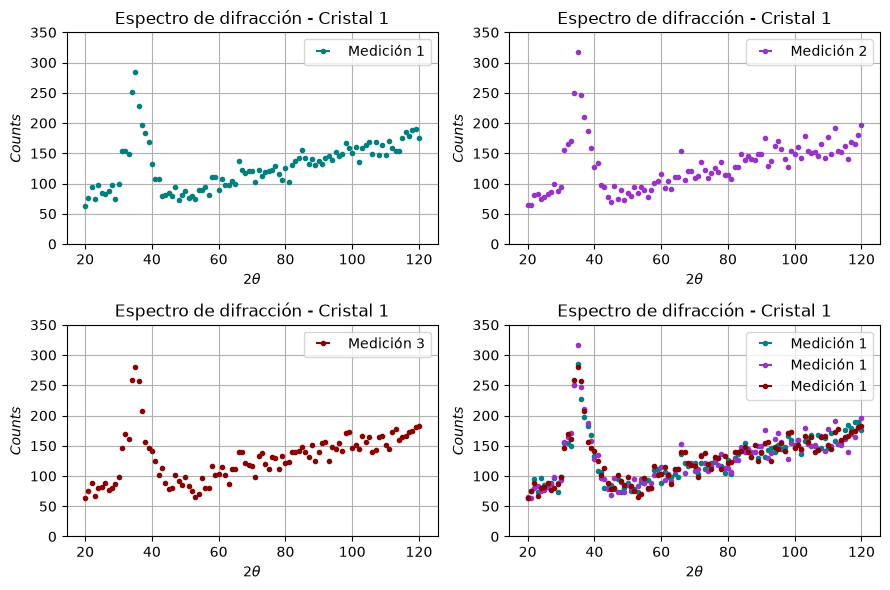

In [74]:
#Gráficas por medición

plt.figure(figsize=(9,6))

plt.subplot(221)
plt.errorbar(Angulo_c1, Medicion1_c1, xerr=Inc_ang_c1,fmt='.',c='teal',label=r'Medición 1')
#plt.plot(Angulo_c1, Medicion1_c1, '.',c='teal',label='Medición 1')
plt.title('Espectro de difracción - Cristal 1')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.ylim(0,350)
plt.legend()
plt.grid()

plt.subplot(222)
plt.errorbar(Angulo_c1, Medicion2_c1, xerr=Inc_ang_c1,fmt='.',c='darkorchid',label=r'Medición 2')
#plt.plot(Angulo_c1, Medicion2_c1, '.',c='darkorchid',label='Medición 2')
plt.title('Espectro de difracción - Cristal 1')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.ylim(0,350)
plt.legend()
plt.grid()

plt.subplot(223)
plt.errorbar(Angulo_c1, Medicion3_c1, xerr=Inc_ang_c1,fmt='.',c='darkred',label=r'Medición 3')
#plt.plot(Angulo_c1,Medicion3_c1,'.',c='darkred',label='Medición 3')
plt.title('Espectro de difracción - Cristal 1')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.ylim(0,350)
plt.legend()
plt.grid()

plt.subplot(224)
plt.errorbar(Angulo_c1, Medicion1_c1, xerr=Inc_ang_c1,fmt='.',c='teal',label=r'Medición 1')
#plt.plot(Angulo_c1, Medicion1_c1, '.',c='teal',label='Medición 1')
plt.errorbar(Angulo_c1, Medicion2_c1, xerr=Inc_ang_c1,fmt='.',c='darkorchid',label=r'Medición 1')
#plt.plot(Angulo_c1, Medicion2_c1, '.',c='darkorchid',label='Medición 2')
plt.errorbar(Angulo_c1, Medicion3_c1, xerr=Inc_ang_c1,fmt='.',c='darkred',label=r'Medición 1')
#plt.plot(Angulo_c1, Medicion3_c1, '.',c='darkred',label='Medición 3')
plt.title('Espectro de difracción - Cristal 1')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.ylim(0,350)
plt.legend()
plt.grid()

plt.tight_layout() # con esta instrucción se autoajustan los espacios entre las gráficas mismas y también con los bordes de la imagen _c1

In [4]:
#Promedio de los datos

Mediciones_c1 = [Medicion1_c1, Medicion2_c1, Medicion3_c1] #Matriz con las tres mediciones
Promedio_c1 = np.mean(Mediciones_c1,axis=0)

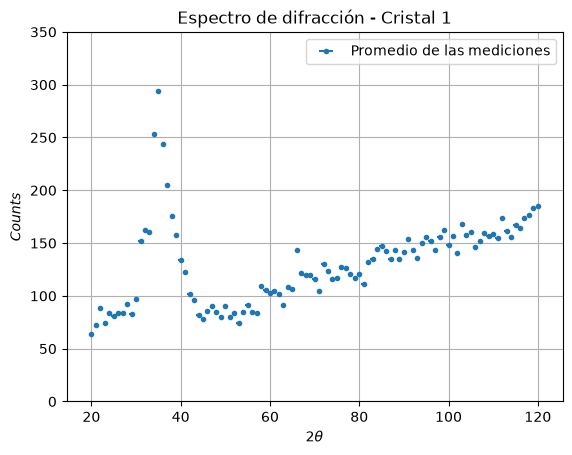

In [32]:
#Gráfica del promedio de las mediciones

plt.errorbar(Angulo_c1, Promedio_c1, xerr=Inc_ang_c1,fmt='.',label=r'Promedio de las mediciones')
#plt.plot(Angulo_c1,Promedio_c1,'.-',c='dodgerblue',label='Promedio de las mediciones')
plt.title('Espectro de difracción - Cristal 1')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.ylim(0,350)
plt.legend()
plt.grid()

In [34]:
#Obtenemos el valor máximo para reportar el ángulo
Promedio_max_c1 = max(Promedio_c1)
Angulo_max_c1 = Angulo_c1[np.argmax(Promedio_c1)]

print('Count (en la versión promedio) max =',Promedio_max_c1)
print('Ángulo max =',Angulo_max_c1)

Count (en la versión promedio) max = 294.0
Ángulo max = 35.0


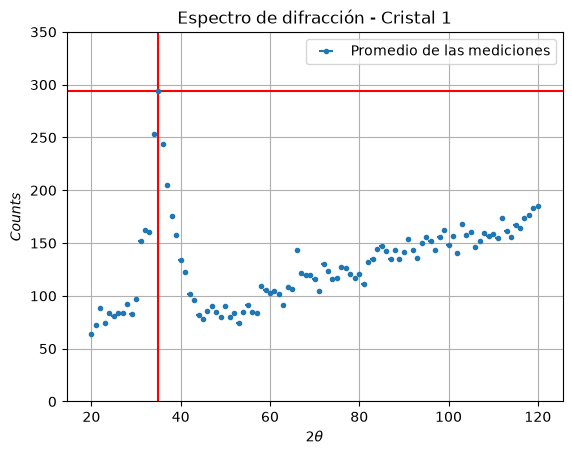

In [35]:
#Gráfica señalando el máximo para corroborar

plt.errorbar(Angulo_c1, Promedio_c1, xerr=Inc_ang_c1,fmt='.',label=r'Promedio de las mediciones')
#plt.plot(Angulo_c1,Promedio_c1,'.-',c='dodgerblue',label='Promedio de las mediciones')
plt.title('Espectro de difracción - Cristal 1')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.axvline(Angulo_max_c1,c='r'), plt.axhline(Promedio_max_c1,c='r') #Máximo
plt.ylim(0,350)
plt.legend()
plt.grid()

La ley de bragg nos dice que
$$ n\lambda = 2 d \sin(\theta) $$
por lo que entonces podemos encontrar la distancia interplanar fácilmente si conocemos los demás parámetros
$$ \Rightarrow d = \frac{n\lambda}{2 \sin(\theta)} $$
en nuestro caso tenemos una longitud de rayos x de $1.54\times 10^{-10} m$. Esta $d$ se podrá encontrar usando el ángulo en donde se forma la interferencia constructiva.

Una cosa a considerar es que la máquina que usamos (TEL-X-OMETER 580) usa una escala de $2\theta$, por lo que entonces el ángulo "real" con el que debemos de trabajar es
$$ \theta = \frac{\text{ángulo medido}}{2} $$

Nosotros registramos un ángulo ($2\theta$) donde se forma la interferencia constructiva de

In [50]:
Angulo_max_c1

35.0

por lo que entonces el valor con el que debemos de trabajar en la ley de Bragg es de

In [51]:
Angulo_max_c1/2

17.5

In [36]:
def ley_bragg(orden,long_onda,angulo):
    # long_onda en metros y angulo en grados
    d = (orden*long_onda)/(2*math.sin(math.radians(angulo)))
    return d

In [52]:
#Calculamos la d de la ley de bragg usando la función que acabamos de definir

ley_bragg(1,1.54*(1e10)**(-1),17.5)

2.560642333035742e-10

## Suavizado de las gráficas (descartado, no funcionó)

In [79]:
filtro = SavgolFilter(window_length_s=9, polyorder_rel=56/60)

filtro.filter(Medicion2_c1, sampling_rate_hz=1)

counts_suavizados = filtro.filtered_data_

plt.plot(Angulo_c1, Medicion2_c1, "o-", label="Datos")
plt.plot(Angulo_c1, counts_suavizados, ".",label="Savitzky-Golay")

plt.xlabel(r"$2\theta$")
plt.ylabel("Counts")
plt.legend()
plt.show()

filtro.window_length_samples_, filtro.polyorder_

TypeError: The passed data is not dataframe-like (i.e. a dataframe, series, or numpy array).

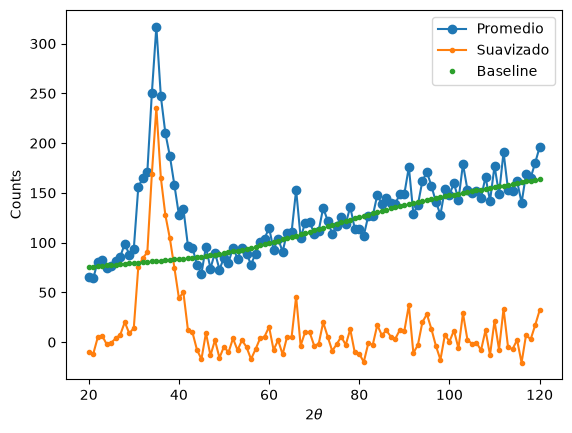

(9, 8)

In [78]:
from pybaselines import Baseline

fitter = Baseline(x_data=Angulo_c1)

baseline, params = fitter.arpls(Medicion2_c1, lam=1e4)

counts_corregidos = Medicion2_c1 - baseline

plt.plot(Angulo_c1, Medicion2_c1, "o-", label="Promedio")
plt.plot(Angulo_c1, counts_corregidos, ".-",label="Suavizado")
plt.plot(Angulo_c1, baseline, ".",label="Baseline")
plt.xlabel(r"$2\theta$")
plt.ylabel("Counts")
plt.legend()
plt.show()

filtro.window_length_samples_, filtro.polyorder_

# Cristal 3

In [53]:
#Obtengo los datos
with open('Cristal-3.csv', mode='r') as archivo:
    ArchivoAbierto = csv.reader(archivo) #Usamos la biblioteca csv
    next(ArchivoAbierto,None)            #Me salto el primer renglón
    Angulo_c3, Inc_ang_c3, Medicion1_c3, Medicion2_c3, Medicion3_c3 = [], [], [], [], []
    for renglon in ArchivoAbierto:
        Angulo_c3.append(float(renglon[0]))
        Inc_ang_c3.append(float(renglon[1]))
        Medicion1_c3.append(float(renglon[2]))
        Medicion2_c3.append(float(renglon[3]))
        Medicion3_c3.append(float(renglon[4]))

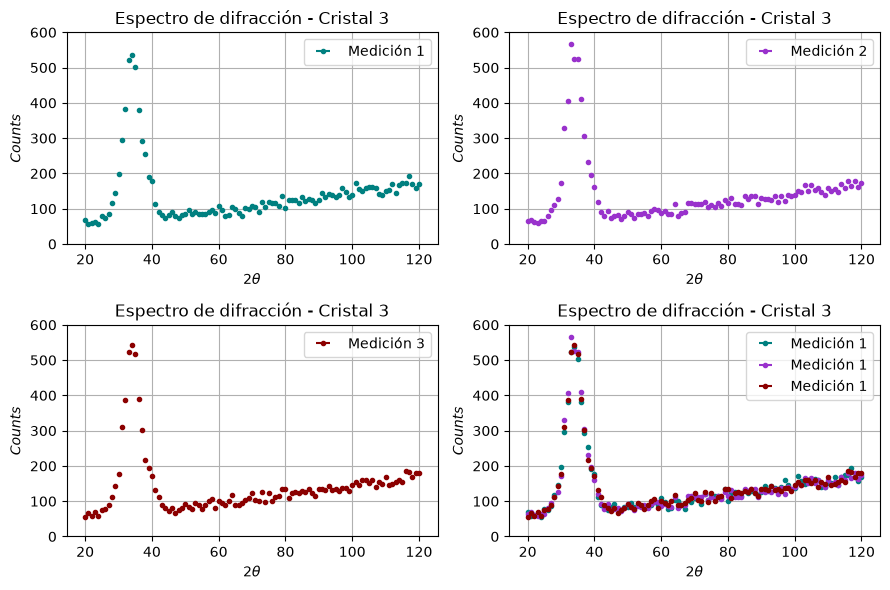

In [56]:
#Gráficas por medición

plt.figure(figsize=(9,6))

plt.subplot(221)
plt.errorbar(Angulo_c3, Medicion1_c3, xerr=Inc_ang_c1,fmt='.',c='teal',label=r'Medición 1')
#plt.plot(Angulo_c3, Medicion1_c3, '.',c='teal',label='Medición 1')
plt.title('Espectro de difracción - Cristal 3')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.ylim(0,600)
plt.legend()
plt.grid()

plt.subplot(222)
plt.errorbar(Angulo_c3, Medicion2_c3, xerr=Inc_ang_c3,fmt='.',c='darkorchid',label=r'Medición 2')
#plt.plot(Angulo_c3, Medicion2_c3, '.',c='darkorchid',label='Medición 2')
plt.title('Espectro de difracción - Cristal 3')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.ylim(0,600)
plt.legend()
plt.grid()

plt.subplot(223)
plt.errorbar(Angulo_c3, Medicion3_c3, xerr=Inc_ang_c3,fmt='.',c='darkred',label=r'Medición 3')
#plt.plot(Angulo_c3,Medicion3_c3,'.',c='darkred',label='Medición 3')
plt.title('Espectro de difracción - Cristal 3')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.ylim(0,600)
plt.legend()
plt.grid()

plt.subplot(224)
plt.errorbar(Angulo_c3, Medicion1_c3, xerr=Inc_ang_c3,fmt='.',c='teal',label=r'Medición 1')
#plt.plot(Angulo_c3, Medicion1_c3, '.',c='teal',label='Medición 1')
plt.errorbar(Angulo_c3, Medicion2_c3, xerr=Inc_ang_c3,fmt='.',c='darkorchid',label=r'Medición 1')
#plt.plot(Angulo_c3, Medicion2_c3, '.',c='darkorchid',label='Medición 2')
plt.errorbar(Angulo_c3, Medicion3_c3, xerr=Inc_ang_c3,fmt='.',c='darkred',label=r'Medición 1')
#plt.plot(Angulo_c3, Medicion3_c3, '.',c='darkred',label='Medición 3')
plt.title('Espectro de difracción - Cristal 3')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.ylim(0,600)
plt.legend()
plt.grid()

plt.tight_layout() # con esta instrucción se autoajustan los espacios entre las gráficas mismas y también con los bordes de la imagen _c1

In [57]:
#Promedio de los datos

Mediciones_c3 = [Medicion1_c3, Medicion2_c3, Medicion3_c3] #Matriz con las tres mediciones
Promedio_c3 = np.mean(Mediciones_c3,axis=0)

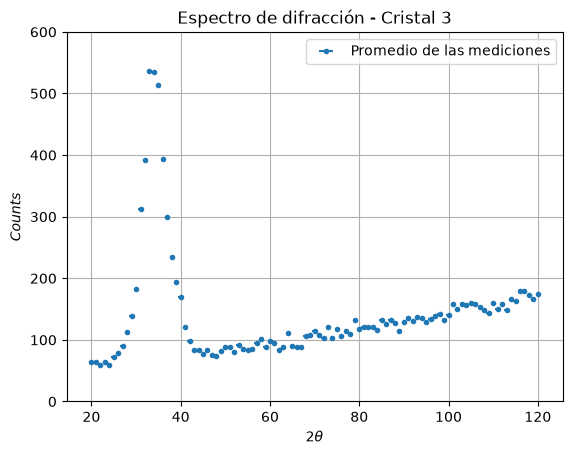

In [82]:
#Gráfica del promedio de las mediciones

plt.errorbar(Angulo_c3, Promedio_c3, xerr=Inc_ang_c3,fmt='.',label=r'Promedio de las mediciones')
#plt.plot(Angulo_c3,Promedio_c3,'.-',c='dodgerblue',label='Promedio de las mediciones')
plt.title('Espectro de difracción - Cristal 3')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.ylim(0,600)
plt.legend()
plt.grid()

In [60]:
#Obtenemos el valor máximo para reportar el ángulo
Promedio_max_c3 = max(Promedio_c3)
Angulo_max_c3 = Angulo_c3[np.argmax(Promedio_c3)]

print('Count (en la versión promedio) max =',Promedio_max_c3)
print('Ángulo max =',Angulo_max_c3)

Count (en la versión promedio) max = 537.0
Ángulo max = 33.0


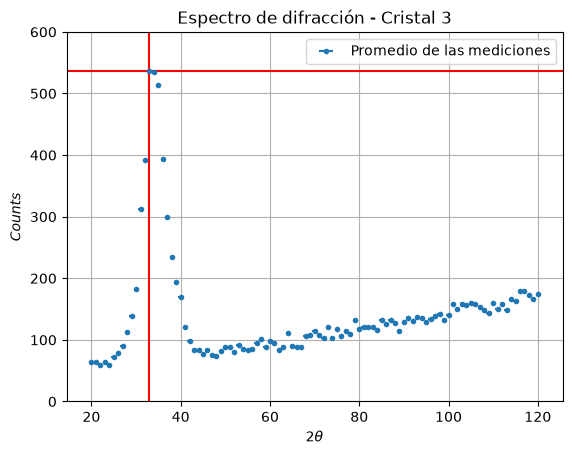

In [63]:
#Gráfica señalando el máximo para corroborar

plt.errorbar(Angulo_c3, Promedio_c3, xerr=Inc_ang_c1,fmt='.',label=r'Promedio de las mediciones')
#plt.plot(Angulo_c3,Promedio_c3,'.-',c='dodgerblue',label='Promedio de las mediciones')
plt.title('Espectro de difracción - Cristal 3')
plt.xlabel(r'$2\theta$'), plt.ylabel(r'$Counts$')
plt.axvline(Angulo_max_c3,c='r'), plt.axhline(Promedio_max_c3,c='r') #Máximo
plt.ylim(0,600)
plt.legend()
plt.grid()

Nosotros registramos un ángulo ($2\theta$) donde se forma la interferencia constructiva de

In [64]:
Angulo_max_c3

33.0

por lo que entonces el valor con el que debemos de trabajar en la ley de Bragg es de

In [65]:
Angulo_max_c3/2

16.5

In [71]:
#Calculamos la d de la ley de bragg usando la función que acabamos de definir

# ley_bragg(orden,long_onda,angulo)
# long_onda en metros y angulo en grados
ley_bragg(1,1.54*(1e10)**(-1),14)

3.182845430717837e-10